In [34]:
# Carga de librerías y datos
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
data = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Limpieza
data['Age'] = data['Age'].fillna(data['Age'].median())
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
data['Fare'] = np.log1p(data['Fare'])
data['familia_total'] = data['SibSp']+data['Parch']+1
data['viajasolo'] = (data['familia_total']==1).astype(int)
data = data.drop(columns=['SibSp','Parch','Name','Ticket','PassengerId','Cabin'])
data.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'familia_total',
       'viajasolo'],
      dtype='object')

In [12]:
# Preparación de datos para el modelo
data = pd.get_dummies(data, columns=['Sex','Pclass', 'Embarked'], drop_first=True)
X = data.drop(columns=['Survived'])
y = data['Survived']
#Dividir el train y el test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test
X, y

KeyError: "None of [Index(['Sex', 'Pclass', 'Embarked'], dtype='object')] are in the [columns]"

In [21]:
# Entrenamiento del modelo
modelo = LogisticRegression(max_iter=1000, random_state=42)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

              precision    recall  f1-score   support

           0       0.81      0.87      0.83       105
           1       0.79      0.70      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



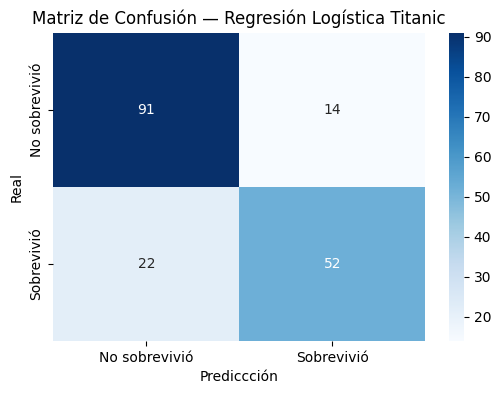

AUC-ROC: 0.8979


In [32]:
# Evaluación del Modelo
print(classification_report(y_test, y_pred))
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['No sobrevivió','Sobrevivió'],
            yticklabels=['No sobrevivió','Sobrevivió'])
plt.title('Matriz de Confusión — Regresión Logística Titanic')
plt.ylabel('Real')
plt.xlabel('Prediccción')
plt.show()
y_proba = modelo.predict_proba(X_test)[:,1]
auc_rl = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC: {auc:.4f}")

In [23]:
# Análisis complementario
coeficientes = pd.DataFrame({
    'variable': X.columns,
    'coeficiente': modelo.coef_[0],
    'odds_ratio': np.exp(modelo.coef_[0])
}).sort_values('odds_ratio', ascending=False)

print(coeficientes)

        variable  coeficiente  odds_ratio
1           Fare     0.393608    1.482320
0            Age    -0.028282    0.972114
7     Embarked_Q    -0.065096    0.936978
5       Pclass_2    -0.185703    0.830520
8     Embarked_S    -0.380085    0.683803
2  familia_total    -0.407820    0.665099
3      viajasolo    -0.508393    0.601461
6       Pclass_3    -1.213609    0.297123
4       Sex_male    -2.520836    0.080392


In [24]:
# Entrenamiento del modelo (Random Forest)
mrf = RandomForestClassifier(n_estimators=1000, random_state=42)
mrf.fit(X_train, y_train)
y_pred2 = mrf.predict(X_test)

              precision    recall  f1-score   support

           0       0.85      0.86      0.85       105
           1       0.79      0.78      0.79        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



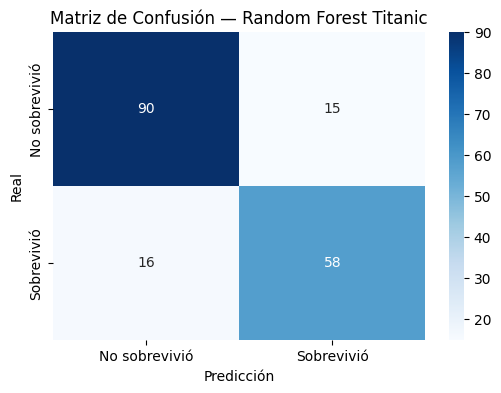

AUC-ROC: 0.8979


In [31]:
# Evaluación del Modelo (Random Forest)
print(classification_report(y_test, y_pred2))
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred2),
            annot=True, fmt='d',cmap='Blues',
            xticklabels=['No sobrevivió', 'Sobrevivió'],
            yticklabels=['No sobrevivió', 'Sobrevivió'])
plt.title('Matriz de Confusión — Random Forest Titanic')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.show()
y_proba2 = mrf.predict_proba(X_test)[:,1]
auc_rf = roc_auc_score(y_test, y_proba2)
print(f"AUC-ROC: {auc_rf:.4f}")

        variable  importancia
1           Fare     0.276756
4       Sex_male     0.273375
0            Age     0.257108
6       Pclass_3     0.068076
2  familia_total     0.063332
8     Embarked_S     0.022905
5       Pclass_2     0.016017
3      viajasolo     0.013101
7     Embarked_Q     0.009329


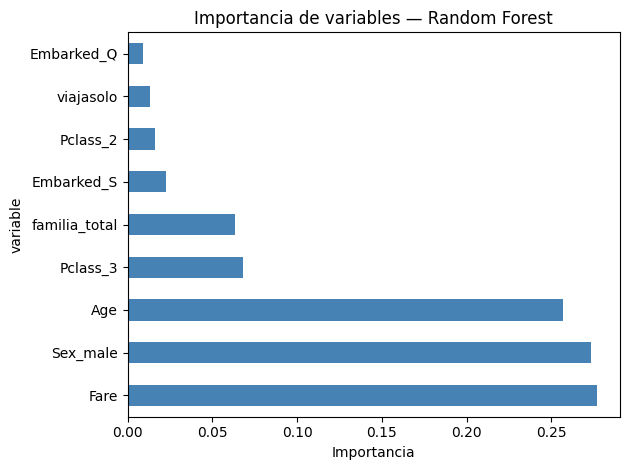

In [29]:
# Importancia de variables en Random Forest
importancias = pd.DataFrame({
    'variable': X.columns,
    'importancia': mrf.feature_importances_
}).sort_values('importancia', ascending=False)

print(importancias)

# Visualización
importancias.plot(kind='barh', x='variable', y='importancia',
                  color='steelblue', legend=False)
plt.title('Importancia de variables — Random Forest')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

In [35]:
# Entrenamiento del modelo (XG Boost)
mgb = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)
mgb.fit(X_train, y_train)
y_pred3 = mgb.predict(X_test)

              precision    recall  f1-score   support

           0       0.83      0.86      0.85       105
           1       0.79      0.76      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.81      0.82      0.82       179



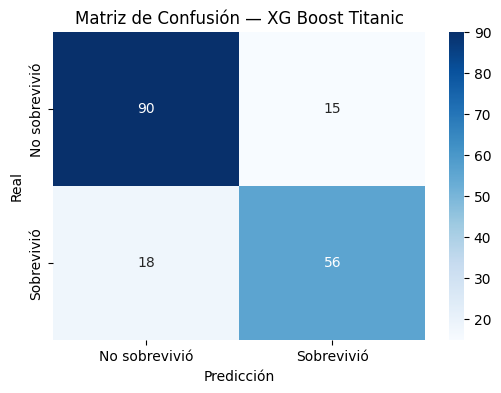

AUC-ROC: 0.8901


In [36]:
#Evaluación del Modelo (XG Boost)
print(classification_report(y_test, y_pred3))
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred3),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['No sobrevivió', 'Sobrevivió'],
            yticklabels=['No sobrevivió', 'Sobrevivió'])
plt.title('Matriz de Confusión — XG Boost Titanic')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.show()
y_proba3 = mgb.predict_proba(X_test)[:,1]
auc_xgb = roc_auc_score(y_test, y_proba3)
print(f"AUC-ROC: {auc_xgb:.4f}")

        variable  importancia
4       Sex_male     0.416991
6       Pclass_3     0.270802
2  familia_total     0.070881
1           Fare     0.052935
8     Embarked_S     0.051887
0            Age     0.049209
5       Pclass_2     0.046009
7     Embarked_Q     0.041286
3      viajasolo     0.000000


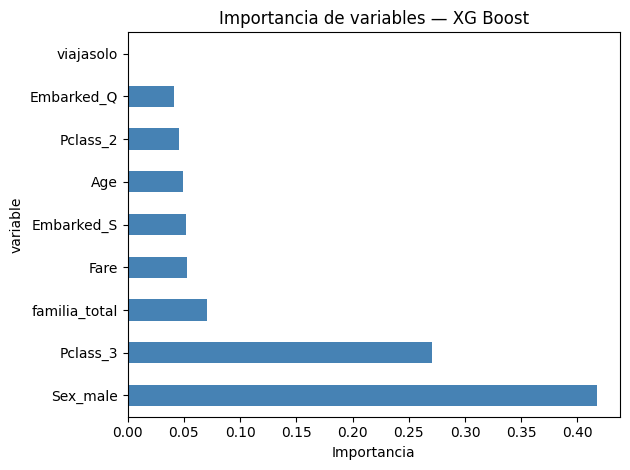

In [38]:
#Importancia de variables en XG Boost
importancias_gb = pd.DataFrame({
    'variable': X.columns,
    'importancia': mgb.feature_importances_
}).sort_values('importancia', ascending=False)
print(importancias_xgb)

#Visualización
importancias_gb.plot(kind='barh', x='variable', y='importancia',
                    color='steelblue', legend=False)
plt.title('Importancia de variables — XG Boost')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

In [33]:
print(classification_report(y_test, y_pred2))
auc_rf = roc_auc_score(y_test, mrf.predict_proba(X_test)[:,1])
print(f"AUC-ROC Random Forest: {auc_rf:.4f}")
print(f"AUC-ROC Regresión Logística: {auc_rl:.4f}")

              precision    recall  f1-score   support

           0       0.85      0.86      0.85       105
           1       0.79      0.78      0.79        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179

AUC-ROC Random Forest: 0.8979
AUC-ROC Regresión Logística: 0.8865
